In [1]:
import pandas as pd

train = ['train_FD001.txt', 'train_FD002.txt', 'train_FD003.txt', 'train_FD004.txt']
test = ['test_FD001.txt', 'test_FD002.txt', 'test_FD003.txt', 'test_FD004.txt']
rul = ['RUL_FD001.txt', 'RUL_FD002.txt', 'RUL_FD003.txt', 'RUL_FD004.txt']
col_names = [
    'unit_id', 'cycle',
    'op_setting_1', 'op_setting_2', 'op_setting_3',
    'sensor_1', 'sensor_2', 'sensor_3', 'sensor_4', 'sensor_5',
    'sensor_6', 'sensor_7', 'sensor_8', 'sensor_9', 'sensor_10',
    'sensor_11', 'sensor_12', 'sensor_13', 'sensor_14', 'sensor_15',
    'sensor_16', 'sensor_17', 'sensor_18', 'sensor_19', 'sensor_20', 'sensor_21'
]

for i in range(4):
    df_train = pd.read_csv(train[i], sep='\s+', header=None, names=col_names)
    df_train['RUL'] = df_train.groupby('unit_id')['cycle'].transform('max') - df_train['cycle']
    df_train['RUL'] = df_train['RUL'].clip(upper=125)
    df_train.to_csv(f'train_{i+1}.csv', index=False)
    train[i] = df_train

    df_test = pd.read_csv(test[i], sep='\s+', header=None, names=col_names)
    df_rul = pd.read_csv(rul[i], sep='\s+', header=None, names=['RUL'])
    max_cycle = df_test.groupby('unit_id')['cycle'].max().reset_index()
    max_cycle.columns = ['unit_id', 'max_cycle']
    max_cycle['RUL_final'] = df_rul['RUL'].values
    max_cycle['total_life'] = max_cycle['max_cycle'] + max_cycle['RUL_final']
    df_test = df_test.merge(max_cycle[['unit_id', 'total_life']], on='unit_id', how='left')
    df_test['RUL'] = df_test['total_life'] - df_test['cycle']
    df_test['RUL'] = df_test['RUL'].clip(upper=125)
    df_test.to_csv(f'test_{i+1}.csv', index=False)
    test[i] = df_test


## 神经网络建模与预测
下面将使用 Keras（TensorFlow）搭建一个简单的全连接神经网络，对RUL进行回归预测。

In [2]:
# 1. 特征选择与数据准备（指定index，统一变量名）
index = 3  # 只用一组数据，1~4可选

# 重新读取指定index的数据
train_df = pd.read_csv(f'train_{index}.csv')
test_df = pd.read_csv(f'test_{index}.csv')

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
import numpy as np

feature_cols = ['op_setting_1', 'op_setting_2', 'op_setting_3', 'sensor_2', 'sensor_3', 'sensor_4', 'sensor_7', 'sensor_8', 'sensor_9', 'sensor_10', 'sensor_11', 'sensor_13', 'sensor_14', 'sensor_15', 'sensor_20', 'sensor_21']
X = train_df[feature_cols].values
y = train_df['RUL'].values

X_train, X_val, y_train, y_val = train_test_split(X, y, test_size=0.2, random_state=42)

scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_val = scaler.transform(X_val)

# 统一 test_df 变量，后续所有预测和评估都用 test_df
X_test = test_df[feature_cols].values
X_test = scaler.transform(X_test)


In [3]:
# 2. 构建LSTM神经网络模型
from tensorflow import keras
from tensorflow.keras import layers

# LSTM需要3D输入：[samples, timesteps, features]
# 这里简单处理：每个样本只用当前时刻特征（timesteps=1），如需滑动窗口可进一步扩展
X_train_lstm = X_train.reshape((X_train.shape[0], 1, X_train.shape[1]))
X_val_lstm = X_val.reshape((X_val.shape[0], 1, X_val.shape[1]))

model = keras.Sequential([
    layers.LSTM(64, input_shape=(1, X_train.shape[1]), return_sequences=False),
    layers.Dense(32, activation='relu'),
    layers.Dense(1)
])

model.compile(optimizer='adam', loss='mse', metrics=['mae'])
model.summary()

RuntimeError: module compiled against ABI version 0x1000009 but this version of numpy is 0x2000000

d:\Python39\lib\site-packages\keras\src\layers\rnn\rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm (LSTM)                     │ (None, 64)             │        20,736 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 22,849 (89.25 KB)

 Trainable params: 22,849 (89.25 KB)

 Non-trainable params: 0 (0.00 B)

In [4]:
# 3. 训练LSTM模型（增加epochs+早停）
from tensorflow.keras.callbacks import EarlyStopping

early_stop = EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True)
history = model.fit(
    X_train_lstm, y_train,
    validation_data=(X_val_lstm, y_val),
    epochs=200,
    batch_size=256,
    verbose=2,
    callbacks=[early_stop]
)

Epoch 1/200
78/78 - 2s - 20ms/step - loss: 9973.5869 - mae: 91.5090 - val_loss: 9274.1279 - val_mae: 88.6691
Epoch 2/200
78/78 - 0s - 3ms/step - loss: 7137.7891 - mae: 77.1874 - val_loss: 4647.5845 - val_mae: 61.4622
Epoch 3/200
78/78 - 0s - 3ms/step - loss: 3012.5444 - mae: 45.7004 - val_loss: 2007.3833 - val_mae: 36.0926
Epoch 4/200
78/78 - 0s - 3ms/step - loss: 1701.5538 - mae: 33.6341 - val_loss: 1491.3289 - val_mae: 31.6154
Epoch 5/200
78/78 - 0s - 3ms/step - loss: 1302.2061 - mae: 29.4820 - val_loss: 1145.6552 - val_mae: 27.4128
Epoch 6/200
78/78 - 0s - 3ms/step - loss: 924.5540 - mae: 24.4396 - val_loss: 718.1522 - val_mae: 21.3410
Epoch 7/200
78/78 - 0s - 3ms/step - loss: 609.2348 - mae: 19.5743 - val_loss: 518.1757 - val_mae: 17.6328
Epoch 8/200
78/78 - 0s - 4ms/step - loss: 461.6190 - mae: 16.4637 - val_loss: 409.7474 - val_mae: 15.1055
Epoch 9/200
78/78 - 0s - 3ms/step - loss: 389.1375 - mae: 14.5257 - val_loss: 359.6044 - val_mae: 13.5983
Epoch 10/200
78/78 - 0s - 3ms/step 

155/155 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step


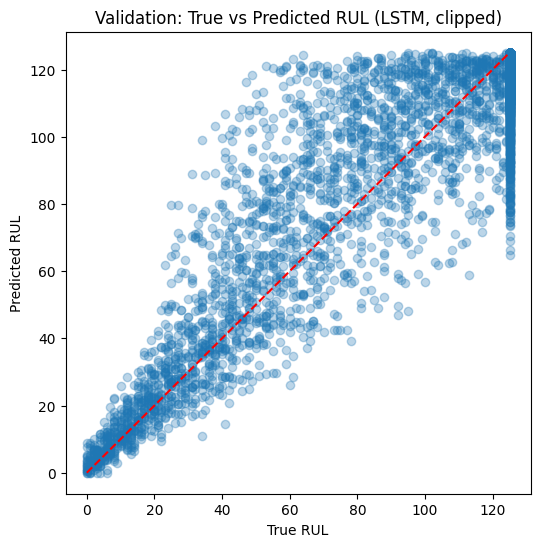

In [5]:
# 5. 验证集预测效果（LSTM，裁剪后可视化）
y_pred = model.predict(X_val_lstm).flatten()
y_pred = np.clip(y_pred, 0, 125)

import matplotlib.pyplot as plt
plt.figure(figsize=(6,6))
plt.scatter(y_val, y_pred, alpha=0.3)
plt.xlabel('True RUL')
plt.ylabel('Predicted RUL')
plt.title('Validation: True vs Predicted RUL (LSTM, clipped)')
plt.plot([y_val.min(), y_val.max()], [y_val.min(), y_val.max()], 'r--')
plt.show()

In [6]:
# 4. 用于测试集预测（LSTM, 指定index，统一变量名，预测后裁剪）
X_test_lstm = X_test.reshape((X_test.shape[0], 1, X_test.shape[1]))
test_df['RUL_pred'] = model.predict(X_test_lstm).flatten()
test_df['RUL_pred'] = np.clip(test_df['RUL_pred'], 0, 125)
test_df[['unit_id', 'cycle', 'RUL', 'RUL_pred']].head()

519/519 ━━━━━━━━━━━━━━━━━━━━ 0s 815us/step


,unit_id,cycle,RUL,RUL_pred
0,1,1,125,122.090065
1,1,2,125,123.690758
2,1,3,125,122.283012
3,1,4,125,123.394432
4,1,5,125,122.369179


In [7]:
# 5. 测试集评估与报告输出（健壮性检查+统一变量名）
from sklearn.metrics import mean_absolute_error, mean_squared_error

# 检查预测列是否存在
if 'RUL_pred' not in test_df.columns:
    raise ValueError("请先运行‘用于测试集预测’单元格，确保 test_df['RUL_pred'] 已生成！")

y_true = test_df['RUL'].values
y_pred = test_df['RUL_pred'].values

mae = mean_absolute_error(y_true, y_pred)
rmse = mean_squared_error(y_true, y_pred) ** 0.5  # 兼容旧版scikit-learn

print(f"测试集 MAE: {mae:.2f}")
print(f"测试集 RMSE: {rmse:.2f}")

# 生成简单报告
def report():
    print("\n===== 测试集预测报告 =====")
    print(f"样本数: {len(y_true)}")
    print(f"MAE: {mae:.2f}")
    print(f"RMSE: {rmse:.2f}")
    print(f"RUL 真实值均值: {np.mean(y_true):.2f}")
    print(f"RUL 预测值均值: {np.mean(y_pred):.2f}")
    print("========================\n")
    print("前5条预测对比:")
    print(test_df[['unit_id', 'cycle', 'RUL', 'RUL_pred']].head())

report()

测试集 MAE: 9.61
测试集 RMSE: 14.96

===== 测试集预测报告 =====
样本数: 16596
MAE: 9.61
RMSE: 14.96
RUL 真实值均值: 112.31
RUL 预测值均值: 111.22

前5条预测对比:
   unit_id  cycle  RUL    RUL_pred
0        1      1  125  122.090065
1        1      2  125  123.690758
2        1      3  125  122.283012
3        1      4  125  123.394432
4        1      5  125  122.369179
